# Object Detection Client

This notebook sends test images to the local FastAPI server and displays the returned prediction image.

In [41]:
# Import the libraries used by the test client.
import io
import os

import cv2
import numpy as np
import requests
from IPython.display import Image, display

In [42]:
# Set the local API address and the model to use.
base_url = "http://127.0.0.1:8000"
endpoint = "/predict"
model = "yolov3-tiny"

In [43]:
# Build the request URL once so it can be reused.
full_url = f"{base_url}{endpoint}?model={model}"
full_url

'http://127.0.0.1:8000/predict?model=yolov3-tiny'

In [44]:
# Send one image file to the server and return the raw HTTP response.
def response_from_server(url, image_file, verbose=True):
    files = {"file": image_file}
    response = requests.post(url, files=files)

    if verbose:
        message = "Everything went well!" if response.status_code == 200 else "There was an error when handling the request."
        print(message)

    return response

In [45]:
# Create a folder for the images returned by the API.
os.makedirs("images_predicted", exist_ok=True)

In [46]:
# Decode the response content, save it, and display it in the notebook.
def display_image_from_response(response, filename="image_with_objects.jpeg"):
    image_stream = io.BytesIO(response.content)
    image_stream.seek(0)
    file_bytes = np.asarray(bytearray(image_stream.read()), dtype=np.uint8)
    image = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    output_path = f"images_predicted/{filename}"
    cv2.imwrite(output_path, image)
    display(Image(output_path))

In [47]:
# Send one sample image to the server.
with open("images/car.jpg", "rb") as image_file:
    prediction = response_from_server(full_url, image_file)

Everything went well!


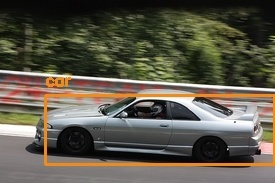

In [48]:
# Display the prediction returned for the sample image.
display_image_from_response(prediction)

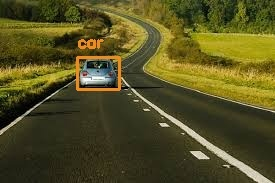

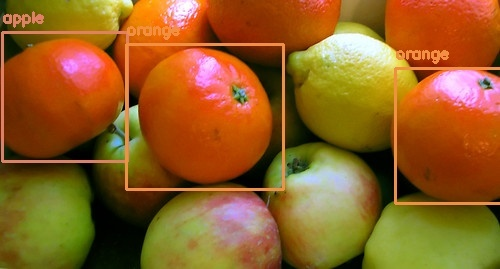

In [49]:
# Try the same request with a small batch of local test images.
image_files = [
    "car3.jpg",
    "fruits.jpg",
]

for image_name in image_files:
    with open(f"images/{image_name}", "rb") as image_file:
        prediction = response_from_server(full_url, image_file, verbose=False)

    display_image_from_response(prediction, filename=f"predicted_{image_name}")